In [8]:

import os
import torch
import numpy as np
import matplotlib
matplotlib.use('Agg') # Stable headless mode for high-volume processing
import matplotlib.pyplot as plt
from tqdm import tqdm
from pyquaternion import Quaternion
from collections import deque
from scipy.interpolate import interp1d
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import Point
from IPython.display import display # <--- NEW: Import Jupyter's display function
from shapely.ops import unary_union
import gc
import random

from nuscenes.nuscenes import NuScenes
from nuscenes.map_expansion.map_api import NuScenesMap

# ================= CONFIGURATION =================
DATAROOT = "/mount/arbeitsdaten/analysis/rasoulta/nuscenes/nuscenes_meta/"
VERSION = "v1.0-trainval"

IMAGE_DIR = "/mount/studenten/projects/rasoulta/dataset/caption-visuals"
PT_DIR = "/mount/studenten/projects/rasoulta/dataset/train_processed_labeled"

TARGET_SAMPLE_COUNT = 500
FORWARD_MAX, BACKWARD_MAX, LATERAL_LIMIT = 50.0, 10.0, 25.0
FIXED_POINT_COUNT = 50 

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(PT_DIR, exist_ok=True)

In [9]:
# ================= GEOMETRY HELPERS =================

def get_yaw(q):
    return Quaternion(q).yaw_pitch_roll[0]

def global_to_local(points_global, ego_translation, ego_rotation):
    pts = np.array(points_global)[:, :2] - np.array(ego_translation[:2])
    yaw = get_yaw(ego_rotation)
    c, s = np.cos(-yaw), np.sin(-yaw)
    rot = np.array([[c, -s], [s, c]])
    local = np.dot(pts, rot.T)
    return np.stack([-local[:, 1], local[:, 0]], axis=1)

def crop_forward_sector(local_coords):
    if len(local_coords) == 0: return local_coords
    x, y = local_coords[:, 0], local_coords[:, 1]
    mask = ((y <= FORWARD_MAX) & (y >= -BACKWARD_MAX) & (np.abs(x) <= LATERAL_LIMIT))
    return local_coords[mask]

# ================= FEATURE & VISUAL LOGIC =================

def calculate_feature_matrix_9col(local_points, ids_in_batch, nmap, ego_trans, ego_rot, target_points=50):
    diffs = np.diff(local_points, axis=0)
    dists = np.linalg.norm(diffs, axis=1)
    cum_dist = np.insert(np.cumsum(dists), 0, 0)
    _, idx = np.unique(cum_dist, return_index=True)
    if len(idx) < 3: return None
    
    pts, cum = local_points[idx], cum_dist[idx]
    total_len = cum[-1]
    if total_len < 1.0: return None

    new_dists = np.linspace(0, total_len, target_points)
    interp_pts = interp1d(cum, pts, axis=0)(new_dists)
    
    g = np.gradient(interp_pts, axis=0)
    norm = np.linalg.norm(g, axis=1)[:, np.newaxis]
    norm[norm == 0] = 1.0
    u = g / norm
    g2 = np.gradient(g, axis=0)
    k = (g[:, 0]*g2[:, 1] - g[:, 1]*g2[:, 0]) / (np.power(norm[:, 0], 3) + 1e-6)
    
    yaw = get_yaw(ego_rot)
    c, s = np.cos(yaw), np.sin(yaw)
    rot_inv = np.array([[c, s], [-s, c]])
    remap_pts = np.stack([interp_pts[:, 1], -interp_pts[:, 0]], axis=1)
    pts_global = np.dot(remap_pts, rot_inv) + np.array(ego_trans[:2])
    
    is_int, is_conn = np.zeros(target_points), np.zeros(target_points)
    center = np.mean(pts_global, axis=0)
    radius = (total_len / 2) + 15
    
    try:
        nearby_road = nmap.get_records_in_radius(center[0], center[1], radius, ['road_segment'])['road_segment']
        junction_polys = [nmap.extract_polygon(nmap.get('road_segment', t)['polygon_token']) 
                         for t in nearby_road if nmap.get('road_segment', t).get('is_intersection', False)]
        junction_zone = unary_union(junction_polys) if junction_polys else None
        nearby_conn = set(nmap.get_records_in_radius(center[0], center[1], radius, ['lane_connector'])['lane_connector'])

        for i in range(target_points):
            p_shapely = Point(pts_global[i,0], pts_global[i,1])
            if junction_zone and junction_zone.contains(p_shapely):
                is_int[i] = 1.0
            closest_lane = nmap.get_closest_lane(pts_global[i,0], pts_global[i,1], radius=3.0)
            if closest_lane in nearby_conn:
                is_conn[i] = 1.0
    except: pass

    return np.stack([interp_pts[:, 0], interp_pts[:, 1], u[:, 0], u[:, 1], 
                    np.clip(k, -0.5, 0.5), new_dists/total_len, np.zeros(target_points),
                    is_int, is_conn], axis=1)

def save_batch_visuals_production(nmap, ego_trans, ego_rot, batches, inf_map, sample_token):
    # --- NEW: Pre-calculate all lane IDs that belong to ANY batch ---
    all_batch_ids = set()
    for _, batch_ids in batches:
        all_batch_ids.update(batch_ids)

    for b_idx, (path_geom, batch_ids) in enumerate(batches):
        num_stages = len(batch_ids) - 1
        for stage in range(1, num_stages + 1):
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), facecolor='black')
            plt.subplots_adjust(wspace=0.02)
            
            for ax in [ax1, ax2]:
                ax.set_facecolor('black')
                ax.set_xlim(-LATERAL_LIMIT, LATERAL_LIMIT)
                ax.set_ylim(-BACKWARD_MAX, FORWARD_MAX)
                ax.axis('off')
                ax.plot(0, 0, 'r^', markersize=14, zorder=100) # Ego position

            # The specific route of interest for this stage
            active_ids = [batch_ids[stage-1], batch_ids[stage]]
            
            # 1. Background paths & Alternative Batches
            for t_id, local_pts in inf_map.items():
                if t_id in active_ids:
                    continue # Skip active route, handled in Step 2
                
                if t_id in all_batch_ids:
                    # --- NEW: Part of SOME batch, but not the active route -> Green ---
                    # Using a slightly thinner line (lw=5) so it doesn't overpower the active route
                    ax1.plot(local_pts[:, 0], local_pts[:, 1], color='#00FF00', lw=5, zorder=25)
                else:
                    # Just a random reachable lane not in any batch -> Dark Gray
                    ax1.plot(local_pts[:, 0], local_pts[:, 1], color='#181818', lw=1.5, zorder=5)

            # 2. Foreground Highlight (Route of Interest) -> Red
            for t_id in active_ids:
                if t_id in inf_map:
                    local_pts = inf_map[t_id]
                    # --- CHANGED: Active route to Red (#FF0000) ---
                    ax1.plot(local_pts[:, 0], local_pts[:, 1], color='#FF0000', lw=10, zorder=50)
                    m = len(local_pts) // 2
                    ax1.text(local_pts[m,0], local_pts[m,1], t_id[:4], color='white', 
                             weight='bold', zorder=60, bbox=dict(facecolor='black', edgecolor='#FF0000', pad=1))

            # 3. Context Map Rendering
            recs = nmap.get_records_in_radius(ego_trans[0], ego_trans[1], 60, ['lane', 'road_segment'])
            for lyr in ['lane', 'road_segment']:
                for t in recs.get(lyr, []):
                    rec = nmap.get(lyr, t)
                    if 'polygon_token' not in rec: continue
                    poly = nmap.extract_polygon(rec['polygon_token'])
                    coords = crop_forward_sector(global_to_local(np.array(poly.exterior.coords)[:,:2], ego_trans, ego_rot))
                    if len(coords) >= 3:
                        ax2.add_patch(MplPolygon(coords, facecolor='#0d0d0d', edgecolor='#1a1a1a', lw=0.5, zorder=1))

            # Overlay Titles
            ax1.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 5, f"BATCH: {b_idx}", color='#FF0000', fontsize=22, weight='bold')
            ax1.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 12, f"STAGE: {stage}", color='#FF0000', fontsize=22, weight='bold')
            ax1.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 19, f"IDs: {active_ids[0][:4]} -> {active_ids[1][:4]}", color='white', fontsize=12)

            # --- CHANGED: Use IPython display to force render the figure ---
            display(fig) 
            
            # Close the figure to free up memory
            plt.close(fig)

# ================= ENGINES =================

def get_reachable_lanes(nmap, trans, rot):
    ego_lane = nmap.get_closest_lane(trans[0], trans[1], radius=5.0)
    if not ego_lane: return {}
    yaw = get_yaw(rot); ego_fwd = np.array([np.cos(yaw), np.sin(yaw)])
    queue, visited, node_path = deque([ego_lane]), set(), {}
    while queue:
        t = queue.popleft()
        if t in visited: continue
        visited.add(t)
        try:
            pts = nmap.discretize_lanes([t], 0.5)[t]
            node_path[t] = np.array(pts)[:, :2]
            for s in nmap.get_outgoing_lane_ids(t): queue.append(s)
            for adj in [nmap.get('lane', t).get('left_lane_token'), nmap.get('lane', t).get('right_lane_token')]:
                if adj: queue.append(adj)
        except: continue
    return node_path

def get_batches(nmap, inf_map):
    legal = set(inf_map.keys())
    roots = sorted([t for t in legal if np.min(np.linalg.norm(inf_map[t], axis=1)) <= 5.0], key=lambda t: np.min(np.linalg.norm(inf_map[t], axis=1)))[:5]
    def walk(curr, chain):
        if len(chain) >= 4 or inf_map[curr][-1, 1] >= FORWARD_MAX: return [chain]
        res = []
        for s in nmap.get_outgoing_lane_ids(curr):
            if s in legal and s not in chain: res.extend(walk(s, chain + [s]))
        return res if res else [chain]
    batches, seen = [], set()
    for r in roots:
        for p in walk(r, [r]):
            if tuple(p) not in seen:
                stitched = np.vstack([inf_map[t] for t in p])
                batches.append((crop_forward_sector(stitched), tuple(p))); seen.add(tuple(p))
    return batches

# ================= MAIN PRODUCTION LOOP =================

def main():
    print(f"[INIT] Loading NuScenes {VERSION}...")
    nusc = NuScenes(version=VERSION, dataroot=DATAROOT, verbose=False)
    
    # Collect every available sample token across all scenes
    all_tokens = []
    for scene in nusc.scene:
        curr = scene['first_sample_token']
        while curr:
            all_tokens.append(curr)
            curr = nusc.get('sample', curr)['next']
    
    # Shuffle for true randomization across maps (Boston + Singapore)
    random.seed(42)
    random.shuffle(all_tokens)
    
    map_cache = {}
    
    print("🔍 Running in TEST MODE: Processing exactly 1 sample to check visuals...")
    
    for token in all_tokens:
        sample = nusc.get('sample', token)
        loc = nusc.get('log', nusc.get('scene', sample['scene_token'])['log_token'])['location']
        nmap = map_cache.setdefault(loc, NuScenesMap(DATAROOT, loc))
        
        ego = nusc.get('ego_pose', nusc.get('sample_data', sample['data']['LIDAR_TOP'])['ego_pose_token'])
        trans, rot = ego['translation'], ego['rotation']
        
        node_paths = get_reachable_lanes(nmap, trans, rot)
        if not node_paths: continue
        
        inf_map = {t: global_to_local(p, trans, rot) for t, p in node_paths.items()}
        batches = get_batches(nmap, inf_map)
        
        if batches:
            valid_sample_found = False
            for b_idx, (path, ids) in enumerate(batches):
                matrix = calculate_feature_matrix_9col(path, ids, nmap, trans, rot)
                if matrix is not None:
                    # Optional: Comment out the next line if you ONLY want to test visuals and not save tensors yet
                    torch.save(torch.from_numpy(matrix).float(), os.path.join(PT_DIR, f"{token}_batch{b_idx}.pt"))
                    valid_sample_found = True
            
            if valid_sample_found:
                print(f"✅ Found valid sample: {token}. Generating visuals...")
                # Save the images with Batch/Stage titles and highlighting
                save_batch_visuals_production(nmap, trans, rot, batches, inf_map, token)
                
                print(f"📸 Visuals saved to {IMAGE_DIR}! Exiting test mode.")
                break # <--- THIS IMMEDIATELY STOPS THE LOOP AFTER ONE SUCCESSFUL FRAME

if __name__ == "__main__":
    main()


[INIT] Loading NuScenes v1.0-trainval...
🔍 Running in TEST MODE: Processing exactly 1 sample to check visuals...
✅ Found valid sample: 548c43e6b3df4717be969ec42da04d3f. Generating visuals...
📸 Visuals saved to /mount/studenten/projects/rasoulta/dataset/caption-visuals! Exiting test mode.


In [11]:
import os
import torch
import numpy as np
import matplotlib
matplotlib.use('Agg') # Stable headless mode forced on. No more UI rendering issues.
import matplotlib.pyplot as plt
from tqdm import tqdm
from pyquaternion import Quaternion
from collections import deque
from scipy.interpolate import interp1d
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import Point
from shapely.ops import unary_union
import gc
import random

from nuscenes.nuscenes import NuScenes
from nuscenes.map_expansion.map_api import NuScenesMap

# ================= CONFIGURATION =================
DATAROOT = "/mount/arbeitsdaten/analysis/rasoulta/nuscenes/nuscenes_meta/"
VERSION = "v1.0-trainval"

# Forcing the output to your current root directory
IMAGE_DIR = "." 
PT_DIR = "/mount/studenten/projects/rasoulta/dataset/train_processed_labeled"

TARGET_SAMPLE_COUNT = 500
FORWARD_MAX, BACKWARD_MAX, LATERAL_LIMIT = 50.0, 10.0, 25.0
FIXED_POINT_COUNT = 50 

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(PT_DIR, exist_ok=True)

# ================= GEOMETRY HELPERS =================

def get_yaw(q):
    return Quaternion(q).yaw_pitch_roll[0]

def global_to_local(points_global, ego_translation, ego_rotation):
    pts = np.array(points_global)[:, :2] - np.array(ego_translation[:2])
    yaw = get_yaw(ego_rotation)
    c, s = np.cos(-yaw), np.sin(-yaw)
    rot = np.array([[c, -s], [s, c]])
    local = np.dot(pts, rot.T)
    return np.stack([-local[:, 1], local[:, 0]], axis=1)

def crop_forward_sector(local_coords):
    if len(local_coords) == 0: return local_coords
    x, y = local_coords[:, 0], local_coords[:, 1]
    mask = ((y <= FORWARD_MAX) & (y >= -BACKWARD_MAX) & (np.abs(x) <= LATERAL_LIMIT))
    return local_coords[mask]

# ================= FEATURE & VISUAL LOGIC =================

def calculate_feature_matrix_9col(local_points, ids_in_batch, nmap, ego_trans, ego_rot, target_points=50):
    diffs = np.diff(local_points, axis=0)
    dists = np.linalg.norm(diffs, axis=1)
    cum_dist = np.insert(np.cumsum(dists), 0, 0)
    _, idx = np.unique(cum_dist, return_index=True)
    if len(idx) < 3: return None
    
    pts, cum = local_points[idx], cum_dist[idx]
    total_len = cum[-1]
    if total_len < 1.0: return None

    new_dists = np.linspace(0, total_len, target_points)
    interp_pts = interp1d(cum, pts, axis=0)(new_dists)
    
    g = np.gradient(interp_pts, axis=0)
    norm = np.linalg.norm(g, axis=1)[:, np.newaxis]
    norm[norm == 0] = 1.0
    u = g / norm
    g2 = np.gradient(g, axis=0)
    k = (g[:, 0]*g2[:, 1] - g[:, 1]*g2[:, 0]) / (np.power(norm[:, 0], 3) + 1e-6)
    
    yaw = get_yaw(ego_rot)
    c, s = np.cos(yaw), np.sin(yaw)
    rot_inv = np.array([[c, s], [-s, c]])
    remap_pts = np.stack([interp_pts[:, 1], -interp_pts[:, 0]], axis=1)
    pts_global = np.dot(remap_pts, rot_inv) + np.array(ego_trans[:2])
    
    is_int, is_conn = np.zeros(target_points), np.zeros(target_points)
    center = np.mean(pts_global, axis=0)
    radius = (total_len / 2) + 15
    
    try:
        nearby_road = nmap.get_records_in_radius(center[0], center[1], radius, ['road_segment'])['road_segment']
        junction_polys = [nmap.extract_polygon(nmap.get('road_segment', t)['polygon_token']) 
                         for t in nearby_road if nmap.get('road_segment', t).get('is_intersection', False)]
        junction_zone = unary_union(junction_polys) if junction_polys else None
        nearby_conn = set(nmap.get_records_in_radius(center[0], center[1], radius, ['lane_connector'])['lane_connector'])

        for i in range(target_points):
            p_shapely = Point(pts_global[i,0], pts_global[i,1])
            if junction_zone and junction_zone.contains(p_shapely):
                is_int[i] = 1.0
            closest_lane = nmap.get_closest_lane(pts_global[i,0], pts_global[i,1], radius=3.0)
            if closest_lane in nearby_conn:
                is_conn[i] = 1.0
    except: pass

    return np.stack([interp_pts[:, 0], interp_pts[:, 1], u[:, 0], u[:, 1], 
                    np.clip(k, -0.5, 0.5), new_dists/total_len, np.zeros(target_points),
                    is_int, is_conn], axis=1)

def save_batch_visuals_production(nmap, ego_trans, ego_rot, batches, inf_map, sample_token):
    all_batch_ids = set()
    for _, batch_ids in batches:
        all_batch_ids.update(batch_ids)

    for b_idx, (path_geom, batch_ids) in enumerate(batches):
        num_stages = len(batch_ids) - 1
        for stage in range(1, num_stages + 1):
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), facecolor='black')
            plt.subplots_adjust(wspace=0.02)
            
            for ax in [ax1, ax2]:
                ax.set_facecolor('black')
                ax.set_xlim(-LATERAL_LIMIT, LATERAL_LIMIT)
                ax.set_ylim(-BACKWARD_MAX, FORWARD_MAX)
                ax.axis('off')
                ax.plot(0, 0, 'r^', markersize=14, zorder=100) # Ego position

            active_ids = [batch_ids[stage-1], batch_ids[stage]]
            
            # 1. Background paths & Alternative Batches
            for t_id, local_pts in inf_map.items():
                if t_id in active_ids:
                    continue 
                
                if t_id in all_batch_ids:
                    # Alternative routes in the batch -> Green
                    ax1.plot(local_pts[:, 0], local_pts[:, 1], color='#00FF00', lw=5, zorder=25)
                else:
                    # Random reachable lanes -> Dark Gray
                    ax1.plot(local_pts[:, 0], local_pts[:, 1], color='#181818', lw=1.5, zorder=5)

            # 2. Foreground Highlight (Route of Interest) -> Red
            for t_id in active_ids:
                if t_id in inf_map:
                    local_pts = inf_map[t_id]
                    ax1.plot(local_pts[:, 0], local_pts[:, 1], color='#FF0000', lw=10, zorder=50)
                    m = len(local_pts) // 2
                    ax1.text(local_pts[m,0], local_pts[m,1], t_id[:4], color='white', 
                             weight='bold', zorder=60, bbox=dict(facecolor='black', edgecolor='#FF0000', pad=1))

            # 3. Context Map Rendering
            recs = nmap.get_records_in_radius(ego_trans[0], ego_trans[1], 60, ['lane', 'road_segment'])
            for lyr in ['lane', 'road_segment']:
                for t in recs.get(lyr, []):
                    rec = nmap.get(lyr, t)
                    if 'polygon_token' not in rec: continue
                    poly = nmap.extract_polygon(rec['polygon_token'])
                    coords = crop_forward_sector(global_to_local(np.array(poly.exterior.coords)[:,:2], ego_trans, ego_rot))
                    if len(coords) >= 3:
                        ax2.add_patch(MplPolygon(coords, facecolor='#0d0d0d', edgecolor='#1a1a1a', lw=0.5, zorder=1))

            # Overlay Titles
            ax1.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 5, f"BATCH: {b_idx}", color='#FF0000', fontsize=22, weight='bold')
            ax1.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 12, f"STAGE: {stage}", color='#FF0000', fontsize=22, weight='bold')
            ax1.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 19, f"IDs: {active_ids[0][:4]} -> {active_ids[1][:4]}", color='white', fontsize=12)

            # Forcing the save directly to the root directory where the script is running
            file_name = f"{sample_token}_batch{b_idx}_stage{stage}.png"
            save_path = os.path.join(IMAGE_DIR, file_name)
            plt.savefig(save_path, facecolor='black', bbox_inches='tight', dpi=100)
            
            # Print the absolute path so there is zero ambiguity about where it went
            print(f"-> Saved visual to: {os.path.abspath(save_path)}")
            
            plt.close(fig)

# ================= ENGINES =================

def get_reachable_lanes(nmap, trans, rot):
    ego_lane = nmap.get_closest_lane(trans[0], trans[1], radius=5.0)
    if not ego_lane: return {}
    yaw = get_yaw(rot); ego_fwd = np.array([np.cos(yaw), np.sin(yaw)])
    queue, visited, node_path = deque([ego_lane]), set(), {}
    while queue:
        t = queue.popleft()
        if t in visited: continue
        visited.add(t)
        try:
            pts = nmap.discretize_lanes([t], 0.5)[t]
            node_path[t] = np.array(pts)[:, :2]
            for s in nmap.get_outgoing_lane_ids(t): queue.append(s)
            for adj in [nmap.get('lane', t).get('left_lane_token'), nmap.get('lane', t).get('right_lane_token')]:
                if adj: queue.append(adj)
        except: continue
    return node_path

def get_batches(nmap, inf_map):
    legal = set(inf_map.keys())
    roots = sorted([t for t in legal if np.min(np.linalg.norm(inf_map[t], axis=1)) <= 5.0], key=lambda t: np.min(np.linalg.norm(inf_map[t], axis=1)))[:5]
    def walk(curr, chain):
        if len(chain) >= 4 or inf_map[curr][-1, 1] >= FORWARD_MAX: return [chain]
        res = []
        for s in nmap.get_outgoing_lane_ids(curr):
            if s in legal and s not in chain: res.extend(walk(s, chain + [s]))
        return res if res else [chain]
    batches, seen = [], set()
    for r in roots:
        for p in walk(r, [r]):
            if tuple(p) not in seen:
                stitched = np.vstack([inf_map[t] for t in p])
                batches.append((crop_forward_sector(stitched), tuple(p))); seen.add(tuple(p))
    return batches

# ================= MAIN PRODUCTION LOOP =================

def main():
    print(f"[INIT] Loading NuScenes {VERSION}...")
    nusc = NuScenes(version=VERSION, dataroot=DATAROOT, verbose=False)
    
    all_tokens = []
    for scene in nusc.scene:
        curr = scene['first_sample_token']
        while curr:
            all_tokens.append(curr)
            curr = nusc.get('sample', curr)['next']
    
    random.seed(42)
    random.shuffle(all_tokens)
    
    map_cache = {}
    
    print("🔍 Running in TEST MODE: Processing exactly 1 sample and saving files...")
    
    for token in all_tokens:
        sample = nusc.get('sample', token)
        loc = nusc.get('log', nusc.get('scene', sample['scene_token'])['log_token'])['location']
        nmap = map_cache.setdefault(loc, NuScenesMap(DATAROOT, loc))
        
        ego = nusc.get('ego_pose', nusc.get('sample_data', sample['data']['LIDAR_TOP'])['ego_pose_token'])
        trans, rot = ego['translation'], ego['rotation']
        
        node_paths = get_reachable_lanes(nmap, trans, rot)
        if not node_paths: continue
        
        inf_map = {t: global_to_local(p, trans, rot) for t, p in node_paths.items()}
        batches = get_batches(nmap, inf_map)
        
        if batches:
            valid_sample_found = False
            for b_idx, (path, ids) in enumerate(batches):
                matrix = calculate_feature_matrix_9col(path, ids, nmap, trans, rot)
                if matrix is not None:
                    valid_sample_found = True
            
            if valid_sample_found:
                print(f"✅ Found valid sample: {token}. Saving images...")
                save_batch_visuals_production(nmap, trans, rot, batches, inf_map, token)
                print(f"📸 Done. Check your current directory for the PNG files.")
                break 

if __name__ == "__main__":
    main()

[INIT] Loading NuScenes v1.0-trainval...
🔍 Running in TEST MODE: Processing exactly 1 sample and saving files...
✅ Found valid sample: 548c43e6b3df4717be969ec42da04d3f. Saving images...
📸 Done. Check your current directory for the PNG files.


In [15]:
import os
import torch
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tqdm import tqdm
from pyquaternion import Quaternion
from collections import deque
from scipy.interpolate import interp1d
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import Point
from shapely.ops import unary_union
import gc
import random

from nuscenes.nuscenes import NuScenes
from nuscenes.map_expansion.map_api import NuScenesMap

# ================= CONFIGURATION =================

DATAROOT = "/mount/arbeitsdaten/analysis/rasoulta/nuscenes/nuscenes_meta/"
VERSION = "v1.0-trainval"

# ✅ FIX: Always use ABSOLUTE PATH
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

IMAGE_DIR = os.path.join(BASE_DIR, "debug_images")
os.makedirs(IMAGE_DIR, exist_ok=True)

print(f"[DEBUG] Base dir: {BASE_DIR}")
print(f"[DEBUG] Saving images to: {IMAGE_DIR}")
IMAGE_DIR = os.path.join(BASE_DIR, "debug_images")

PT_DIR = "/mount/studenten/projects/rasoulta/dataset/train_processed_labeled"

TARGET_SAMPLE_COUNT = 500
FORWARD_MAX, BACKWARD_MAX, LATERAL_LIMIT = 50.0, 10.0, 25.0
FIXED_POINT_COUNT = 50 

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(PT_DIR, exist_ok=True)

nusc = NuScenes(version=VERSION, dataroot=DATAROOT, verbose=False)


# ================= DEBUG =================
print(f"[DEBUG] Current working directory: {os.getcwd()}")
print(f"[DEBUG] Images will be saved to: {IMAGE_DIR}")


[DEBUG] Base dir: /mount/arbeitsdaten65/studenten4/rasoulta/HiVT-Caption
[DEBUG] Saving images to: /mount/arbeitsdaten65/studenten4/rasoulta/HiVT-Caption/debug_images
[DEBUG] Current working directory: /mount/arbeitsdaten65/studenten4/rasoulta/HiVT-Caption
[DEBUG] Images will be saved to: /mount/arbeitsdaten65/studenten4/rasoulta/HiVT-Caption/debug_images


In [21]:
# ================= GEOMETRY HELPERS =================

def get_yaw(q):
    return Quaternion(q).yaw_pitch_roll[0]

def global_to_local(points_global, ego_translation, ego_rotation):
    pts = np.array(points_global)[:, :2] - np.array(ego_translation[:2])
    yaw = get_yaw(ego_rotation)
    c, s = np.cos(-yaw), np.sin(-yaw)
    rot = np.array([[c, -s], [s, c]])
    local = np.dot(pts, rot.T)
    return np.stack([-local[:, 1], local[:, 0]], axis=1)

def crop_forward_sector(local_coords):
    if len(local_coords) == 0:
        return local_coords
    x, y = local_coords[:, 0], local_coords[:, 1]
    mask = ((y <= FORWARD_MAX) & (y >= -BACKWARD_MAX) & (np.abs(x) <= LATERAL_LIMIT))
    return local_coords[mask]

# ================= FEATURE =================

def calculate_feature_matrix_9col(local_points, ids_in_batch, nmap, ego_trans, ego_rot, target_points=50):
    if len(local_points) < 3: return None
    diffs = np.diff(local_points, axis=0)
    dists = np.linalg.norm(diffs, axis=1)
    cum_dist = np.insert(np.cumsum(dists), 0, 0)
    _, idx = np.unique(cum_dist, return_index=True)
    if len(idx) < 3: return None
    pts, cum = local_points[idx], cum_dist[idx]
    total_len = cum[-1]
    if total_len < 1.0: return None
    new_dists = np.linspace(0, total_len, target_points)
    interp_pts = interp1d(cum, pts, axis=0)(new_dists)
    g = np.gradient(interp_pts, axis=0)
    norm = np.linalg.norm(g, axis=1)[:, np.newaxis]
    norm[norm == 0] = 1.0
    u = g / norm
    g2 = np.gradient(g, axis=0)
    k = (g[:, 0]*g2[:, 1] - g[:, 1]*g2[:, 0]) / (np.power(norm[:, 0], 3) + 1e-6)
    yaw = get_yaw(ego_rot)
    c, s = np.cos(yaw), np.sin(yaw)
    rot_inv = np.array([[c, s], [-s, c]])
    remap_pts = np.stack([interp_pts[:, 1], -interp_pts[:, 0]], axis=1)
    pts_global = np.dot(remap_pts, rot_inv) + np.array(ego_trans[:2])
    is_int, is_conn = np.zeros(target_points), np.zeros(target_points)
    try:
        center = np.mean(pts_global, axis=0)
        radius = (total_len / 2) + 15
        nearby_road = nmap.get_records_in_radius(center[0], center[1], radius, ['road_segment'])['road_segment']
        junction_polys = [
            nmap.extract_polygon(nmap.get('road_segment', t)['polygon_token'])
            for t in nearby_road
            if nmap.get('road_segment', t).get('is_intersection', False)
        ]
        junction_zone = unary_union(junction_polys) if junction_polys else None
        nearby_conn = set(nmap.get_records_in_radius(center[0], center[1], radius, ['lane_connector'])['lane_connector'])
        for i in range(target_points):
            p = Point(pts_global[i, 0], pts_global[i, 1])
            if junction_zone and junction_zone.contains(p):
                is_int[i] = 1.0
            closest_lane = nmap.get_closest_lane(pts_global[i, 0], pts_global[i, 1], radius=3.0)
            if closest_lane in nearby_conn:
                is_conn[i] = 1.0
    except Exception as e:
        print("[WARN] Feature calc error:", e)
    return np.stack([
        interp_pts[:, 0], interp_pts[:, 1], u[:, 0], u[:, 1],
        np.clip(k, -0.5, 0.5), new_dists / total_len, np.zeros(target_points),
        is_int, is_conn
    ], axis=1)

# ================= VISUAL =================

def save_batch_visuals_production(nmap, ego_trans, ego_rot, batches, inf_map, sample_token):
    save_count = 0

    # ✅ Collect every lane ID that belongs to ANY batch for green highlighting
    all_batch_ids = set()
    for _, batch_ids in batches:
        all_batch_ids.update(batch_ids)

    for b_idx, (path_geom, batch_ids) in enumerate(batches):
        if len(batch_ids) < 2:
            continue

        for stage in range(1, len(batch_ids)):
            fig, ax = plt.subplots(figsize=(10, 10), facecolor='black')
            ax.set_facecolor('black')
            ax.set_xlim(-LATERAL_LIMIT, LATERAL_LIMIT)
            ax.set_ylim(-BACKWARD_MAX, FORWARD_MAX)
            ax.axis('off')
            ax.plot(0, 0, 'r^', markersize=12, zorder=100)

            active_ids = [batch_ids[stage-1], batch_ids[stage]]

            # ✅ Render Background vs Alternative Batches
            for t_id, pts in inf_map.items():
                if t_id in active_ids:
                    continue 
                
                if t_id in all_batch_ids:
                    # In another batch -> Green
                    ax.plot(pts[:, 0], pts[:, 1], color='#00FF00', lw=3, zorder=25)
                else:
                    # Random reachable lane -> Dark Gray
                    ax.plot(pts[:, 0], pts[:, 1], color='#181818', lw=1, zorder=5)

            # ✅ Render Active Route
            for t_id in active_ids:
                if t_id in inf_map:
                    pts = inf_map[t_id]
                    # Route of interest -> Red
                    ax.plot(pts[:, 0], pts[:, 1], color='#FF0000', lw=6, zorder=50)

            # Titles
            ax.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 3, f"BATCH: {b_idx}", color='#FF0000', fontsize=16, weight='bold')
            ax.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 6, f"STAGE: {stage}", color='#FF0000', fontsize=16, weight='bold')

            file_name = f"{sample_token}_b{b_idx}_s{stage}.png"
            save_path = os.path.join(IMAGE_DIR, file_name)

            plt.savefig(save_path, dpi=100, bbox_inches='tight', facecolor='black')
            plt.close(fig)

            print(f"[SAVE] {os.path.abspath(save_path)}")
            save_count += 1

    print(f"[INFO] Total images saved for this frame: {save_count}")

# ================= PIPELINE =================

def get_reachable_lanes(nmap, trans, rot):
    ego_lane = nmap.get_closest_lane(trans[0], trans[1], radius=5.0)
    if not ego_lane: return {}
    queue, visited, node_path = deque([ego_lane]), set(), {}
    while queue:
        t = queue.popleft()
        if t in visited: continue
        visited.add(t)
        try:
            pts = nmap.discretize_lanes([t], 0.5)[t]
            node_path[t] = np.array(pts)[:, :2]
            for s in nmap.get_outgoing_lane_ids(t): queue.append(s)
            lane = nmap.get('lane', t)
            for adj in [lane.get('left_lane_token'), lane.get('right_lane_token')]:
                if adj: queue.append(adj)
        except: continue
    return node_path

def get_batches(nmap, inf_map):
    legal = set(inf_map.keys())
    roots = list(legal)[:5]
    def walk(curr, chain):
        if len(chain) >= 4: return [chain]
        res = []
        for s in nmap.get_outgoing_lane_ids(curr):
            if s in legal and s not in chain: res.extend(walk(s, chain + [s]))
        return res if res else [chain]
    batches = []
    for r in roots:
        for p in walk(r, [r]):
            stitched = np.vstack([inf_map[t] for t in p])
            batches.append((stitched, tuple(p)))
    return batches

# ================= MAIN =================

def main():
    print("[INIT] Loading NuScenes...")

    tokens = []
    for scene in nusc.scene:
        curr = scene['first_sample_token']
        while curr:
            tokens.append(curr)
            curr = nusc.get('sample', curr)['next']

    random.seed(42)
    random.shuffle(tokens)

    for token in tokens:
        sample = nusc.get('sample', token)
        ego = nusc.get('ego_pose', nusc.get('sample_data', sample['data']['LIDAR_TOP'])['ego_pose_token'])
        trans, rot = ego['translation'], ego['rotation']
        loc = nusc.get('log', nusc.get('scene', sample['scene_token'])['log_token'])['location']

        nmap = NuScenesMap(DATAROOT, loc)
        node_paths = get_reachable_lanes(nmap, trans, rot)
        if not node_paths: continue

        inf_map = {t: global_to_local(p, trans, rot) for t, p in node_paths.items()}
        batches = get_batches(nmap, inf_map)
        
        if not batches: continue

        print(f"[FOUND] Valid frame: {token}")
        save_batch_visuals_production(nmap, trans, rot, batches, inf_map, token)
        
        # ✅ FIX: STOP IMMEDIATELY AFTER ONE FRAME IS PROCESSED
        print("[DONE] Exiting after processing exactly 1 frame.")
        break 

if __name__ == "__main__":
    main()

[INIT] Loading NuScenes...
[FOUND] Valid frame: 548c43e6b3df4717be969ec42da04d3f
[SAVE] /mount/arbeitsdaten65/studenten4/rasoulta/HiVT-Caption/debug_images/548c43e6b3df4717be969ec42da04d3f_b0_s1.png
[SAVE] /mount/arbeitsdaten65/studenten4/rasoulta/HiVT-Caption/debug_images/548c43e6b3df4717be969ec42da04d3f_b1_s1.png
[SAVE] /mount/arbeitsdaten65/studenten4/rasoulta/HiVT-Caption/debug_images/548c43e6b3df4717be969ec42da04d3f_b1_s2.png
[SAVE] /mount/arbeitsdaten65/studenten4/rasoulta/HiVT-Caption/debug_images/548c43e6b3df4717be969ec42da04d3f_b1_s3.png
[SAVE] /mount/arbeitsdaten65/studenten4/rasoulta/HiVT-Caption/debug_images/548c43e6b3df4717be969ec42da04d3f_b2_s1.png
[SAVE] /mount/arbeitsdaten65/studenten4/rasoulta/HiVT-Caption/debug_images/548c43e6b3df4717be969ec42da04d3f_b3_s1.png
[SAVE] /mount/arbeitsdaten65/studenten4/rasoulta/HiVT-Caption/debug_images/548c43e6b3df4717be969ec42da04d3f_b3_s2.png
[SAVE] /mount/arbeitsdaten65/studenten4/rasoulta/HiVT-Caption/debug_images/548c43e6b3df4717be

In [22]:

import os
import torch
import numpy as np
import matplotlib
matplotlib.use('Agg') # Stable headless mode for high-volume processing
import matplotlib.pyplot as plt
from tqdm import tqdm
from pyquaternion import Quaternion
from collections import deque
from scipy.interpolate import interp1d
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import Point
from shapely.ops import unary_union
import gc
import random

from nuscenes.nuscenes import NuScenes
from nuscenes.map_expansion.map_api import NuScenesMap

# ================= CONFIGURATION =================
DATAROOT = "/mount/arbeitsdaten/analysis/rasoulta/nuscenes/nuscenes_meta/"
VERSION = "v1.0-trainval"

IMAGE_DIR = "/mount/studenten/projects/rasoulta/dataset/caption-visuals"
PT_DIR = "/mount/studenten/projects/rasoulta/dataset/train_processed_labeled"

TARGET_SAMPLE_COUNT = 500
FORWARD_MAX, BACKWARD_MAX, LATERAL_LIMIT = 50.0, 10.0, 25.0
FIXED_POINT_COUNT = 50 

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(PT_DIR, exist_ok=True)

print(f"[INIT] Loading NuScenes {VERSION}...")
nusc = NuScenes(version=VERSION, dataroot=DATAROOT, verbose=False)



[INIT] Loading NuScenes v1.0-trainval...


🎲 Processing Randomized Samples:   1%|▎                                            | 3/500 [09:55<27:24:58, 198.59s/it]


In [23]:
# ================= GEOMETRY HELPERS =================

def get_yaw(q):
    return Quaternion(q).yaw_pitch_roll[0]

def global_to_local(points_global, ego_translation, ego_rotation):
    pts = np.array(points_global)[:, :2] - np.array(ego_translation[:2])
    yaw = get_yaw(ego_rotation)
    c, s = np.cos(-yaw), np.sin(-yaw)
    rot = np.array([[c, -s], [s, c]])
    local = np.dot(pts, rot.T)
    return np.stack([-local[:, 1], local[:, 0]], axis=1)

def crop_forward_sector(local_coords):
    if len(local_coords) == 0: return local_coords
    x, y = local_coords[:, 0], local_coords[:, 1]
    mask = ((y <= FORWARD_MAX) & (y >= -BACKWARD_MAX) & (np.abs(x) <= LATERAL_LIMIT))
    return local_coords[mask]

# ================= FEATURE & VISUAL LOGIC =================

def calculate_feature_matrix_9col(local_points, ids_in_batch, nmap, ego_trans, ego_rot, target_points=50):
    diffs = np.diff(local_points, axis=0)
    dists = np.linalg.norm(diffs, axis=1)
    cum_dist = np.insert(np.cumsum(dists), 0, 0)
    _, idx = np.unique(cum_dist, return_index=True)
    if len(idx) < 3: return None
    
    pts, cum = local_points[idx], cum_dist[idx]
    total_len = cum[-1]
    if total_len < 1.0: return None

    new_dists = np.linspace(0, total_len, target_points)
    interp_pts = interp1d(cum, pts, axis=0)(new_dists)
    
    g = np.gradient(interp_pts, axis=0)
    norm = np.linalg.norm(g, axis=1)[:, np.newaxis]
    norm[norm == 0] = 1.0
    u = g / norm
    g2 = np.gradient(g, axis=0)
    k = (g[:, 0]*g2[:, 1] - g[:, 1]*g2[:, 0]) / (np.power(norm[:, 0], 3) + 1e-6)
    
    yaw = get_yaw(ego_rot)
    c, s = np.cos(yaw), np.sin(yaw)
    rot_inv = np.array([[c, s], [-s, c]])
    remap_pts = np.stack([interp_pts[:, 1], -interp_pts[:, 0]], axis=1)
    pts_global = np.dot(remap_pts, rot_inv) + np.array(ego_trans[:2])
    
    is_int, is_conn = np.zeros(target_points), np.zeros(target_points)
    center = np.mean(pts_global, axis=0)
    radius = (total_len / 2) + 15
    
    try:
        nearby_road = nmap.get_records_in_radius(center[0], center[1], radius, ['road_segment'])['road_segment']
        junction_polys = [nmap.extract_polygon(nmap.get('road_segment', t)['polygon_token']) 
                         for t in nearby_road if nmap.get('road_segment', t).get('is_intersection', False)]
        junction_zone = unary_union(junction_polys) if junction_polys else None
        nearby_conn = set(nmap.get_records_in_radius(center[0], center[1], radius, ['lane_connector'])['lane_connector'])

        for i in range(target_points):
            p_shapely = Point(pts_global[i,0], pts_global[i,1])
            if junction_zone and junction_zone.contains(p_shapely):
                is_int[i] = 1.0
            closest_lane = nmap.get_closest_lane(pts_global[i,0], pts_global[i,1], radius=3.0)
            if closest_lane in nearby_conn:
                is_conn[i] = 1.0
    except: pass

    return np.stack([interp_pts[:, 0], interp_pts[:, 1], u[:, 0], u[:, 1], 
                    np.clip(k, -0.5, 0.5), new_dists/total_len, np.zeros(target_points),
                    is_int, is_conn], axis=1)

def save_batch_visuals_production(nmap, ego_trans, ego_rot, batches, inf_map, sample_token):
    for b_idx, (path_geom, batch_ids) in enumerate(batches):
        num_stages = len(batch_ids) - 1
        for stage in range(1, num_stages + 1):
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), facecolor='black')
            plt.subplots_adjust(wspace=0.02)
            
            for ax in [ax1, ax2]:
                ax.set_facecolor('black')
                ax.set_xlim(-LATERAL_LIMIT, LATERAL_LIMIT)
                ax.set_ylim(-BACKWARD_MAX, FORWARD_MAX)
                ax.axis('off')
                ax.plot(0, 0, 'r^', markersize=14, zorder=100) # Ego position

            active_ids = [batch_ids[stage-1], batch_ids[stage]]
            
            # 1. Background paths
            for t_id, local_pts in inf_map.items():
                if t_id not in active_ids:
                    ax1.plot(local_pts[:, 0], local_pts[:, 1], color='#181818', lw=1.5, zorder=5)

            # 2. Foreground Highlight (High visibility)
            for t_id in active_ids:
                if t_id in inf_map:
                    local_pts = inf_map[t_id]
                    ax1.plot(local_pts[:, 0], local_pts[:, 1], color='#00FF00', lw=10, zorder=50)
                    m = len(local_pts) // 2
                    ax1.text(local_pts[m,0], local_pts[m,1], t_id[:4], color='white', 
                             weight='bold', zorder=60, bbox=dict(facecolor='black', edgecolor='#00FF00', pad=1))

            # 3. Context Map Rendering
            recs = nmap.get_records_in_radius(ego_trans[0], ego_trans[1], 60, ['lane', 'road_segment'])
            for lyr in ['lane', 'road_segment']:
                for t in recs.get(lyr, []):
                    rec = nmap.get(lyr, t)
                    if 'polygon_token' not in rec: continue
                    poly = nmap.extract_polygon(rec['polygon_token'])
                    coords = crop_forward_sector(global_to_local(np.array(poly.exterior.coords)[:,:2], ego_trans, ego_rot))
                    if len(coords) >= 3:
                        ax2.add_patch(MplPolygon(coords, facecolor='#0d0d0d', edgecolor='#1a1a1a', lw=0.5, zorder=1))

            # Overlay Titles
            ax1.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 5, f"BATCH: {b_idx}", color='#00FF00', fontsize=22, weight='bold')
            ax1.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 12, f"STAGE: {stage}", color='#00FF00', fontsize=22, weight='bold')
            ax1.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 19, f"IDs: {active_ids[0][:4]} -> {active_ids[1][:4]}", color='white', fontsize=12)

            plt.savefig(os.path.join(IMAGE_DIR, f"{sample_token}_batch{b_idx}_stage{stage}.png"), facecolor='black', bbox_inches='tight', dpi=100)
            plt.close(fig)

# ================= ENGINES =================

def get_reachable_lanes(nmap, trans, rot):
    ego_lane = nmap.get_closest_lane(trans[0], trans[1], radius=5.0)
    if not ego_lane: return {}
    yaw = get_yaw(rot); ego_fwd = np.array([np.cos(yaw), np.sin(yaw)])
    queue, visited, node_path = deque([ego_lane]), set(), {}
    while queue:
        t = queue.popleft()
        if t in visited: continue
        visited.add(t)
        try:
            pts = nmap.discretize_lanes([t], 0.5)[t]
            node_path[t] = np.array(pts)[:, :2]
            for s in nmap.get_outgoing_lane_ids(t): queue.append(s)
            for adj in [nmap.get('lane', t).get('left_lane_token'), nmap.get('lane', t).get('right_lane_token')]:
                if adj: queue.append(adj)
        except: continue
    return node_path

def get_batches(nmap, inf_map):
    legal = set(inf_map.keys())
    roots = sorted([t for t in legal if np.min(np.linalg.norm(inf_map[t], axis=1)) <= 5.0], key=lambda t: np.min(np.linalg.norm(inf_map[t], axis=1)))[:5]
    def walk(curr, chain):
        if len(chain) >= 4 or inf_map[curr][-1, 1] >= FORWARD_MAX: return [chain]
        res = []
        for s in nmap.get_outgoing_lane_ids(curr):
            if s in legal and s not in chain: res.extend(walk(s, chain + [s]))
        return res if res else [chain]
    batches, seen = [], set()
    for r in roots:
        for p in walk(r, [r]):
            if tuple(p) not in seen:
                stitched = np.vstack([inf_map[t] for t in p])
                batches.append((crop_forward_sector(stitched), tuple(p))); seen.add(tuple(p))
    return batches

# ================= MAIN PRODUCTION LOOP =================

def main():

    # Collect every available sample token across all scenes
    all_tokens = []
    for scene in nusc.scene:
        curr = scene['first_sample_token']
        while curr:
            all_tokens.append(curr)
            curr = nusc.get('sample', curr)['next']
    
    # Shuffle for true randomization across maps (Boston + Singapore)
    random.seed(42)
    random.shuffle(all_tokens)
    
    map_cache = {}
    count = 0
    pbar = tqdm(total=TARGET_SAMPLE_COUNT, desc="🎲 Processing Randomized Samples")
    
    for token in all_tokens:
        if count >= TARGET_SAMPLE_COUNT: break
        
        sample = nusc.get('sample', token)
        loc = nusc.get('log', nusc.get('scene', sample['scene_token'])['log_token'])['location']
        nmap = map_cache.setdefault(loc, NuScenesMap(DATAROOT, loc))
        
        ego = nusc.get('ego_pose', nusc.get('sample_data', sample['data']['LIDAR_TOP'])['ego_pose_token'])
        trans, rot = ego['translation'], ego['rotation']
        
        node_paths = get_reachable_lanes(nmap, trans, rot)
        if not node_paths: continue
        
        inf_map = {t: global_to_local(p, trans, rot) for t, p in node_paths.items()}
        batches = get_batches(nmap, inf_map)
        
        if batches:
            valid_sample_found = False
            for b_idx, (path, ids) in enumerate(batches):
                matrix = calculate_feature_matrix_9col(path, ids, nmap, trans, rot)
                if matrix is not None:
                    torch.save(torch.from_numpy(matrix).float(), os.path.join(PT_DIR, f"{token}_batch{b_idx}.pt"))
                    valid_sample_found = True
            
            if valid_sample_found:
                # Save the images with Batch/Stage titles and 10px green highlighting
                save_batch_visuals_production(nmap, trans, rot, batches, inf_map, token)
                count += 1
                pbar.update(1)
            
            if count % 10 == 0: gc.collect() # Regular memory clearing

Initializing NuScenes...
Hunting for a random sample with multiple routes...
Found 3 possible routes for sample: 89c3b80f8947457a884a13201a781c11


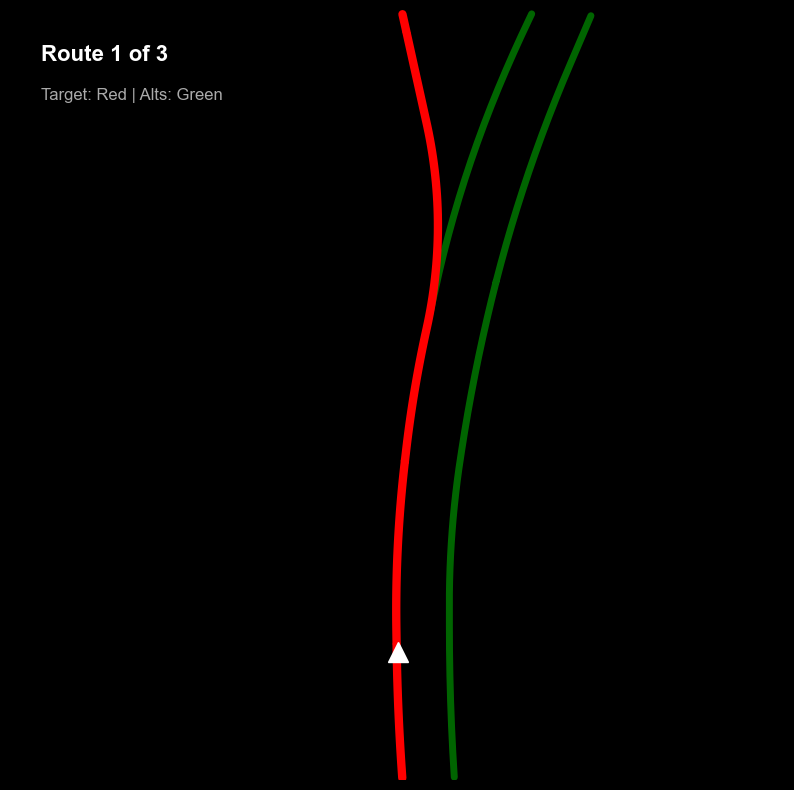

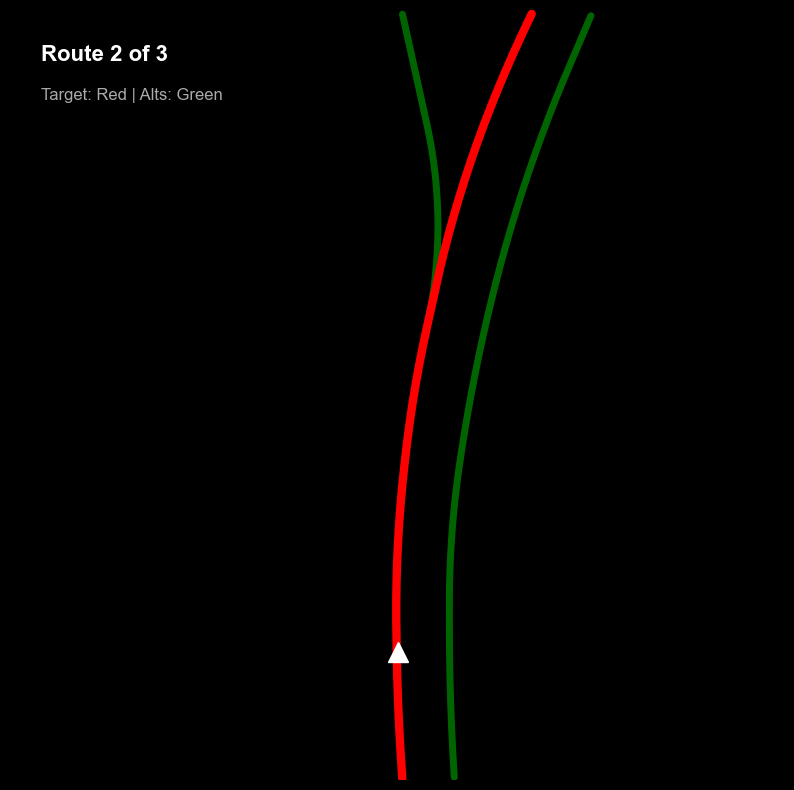

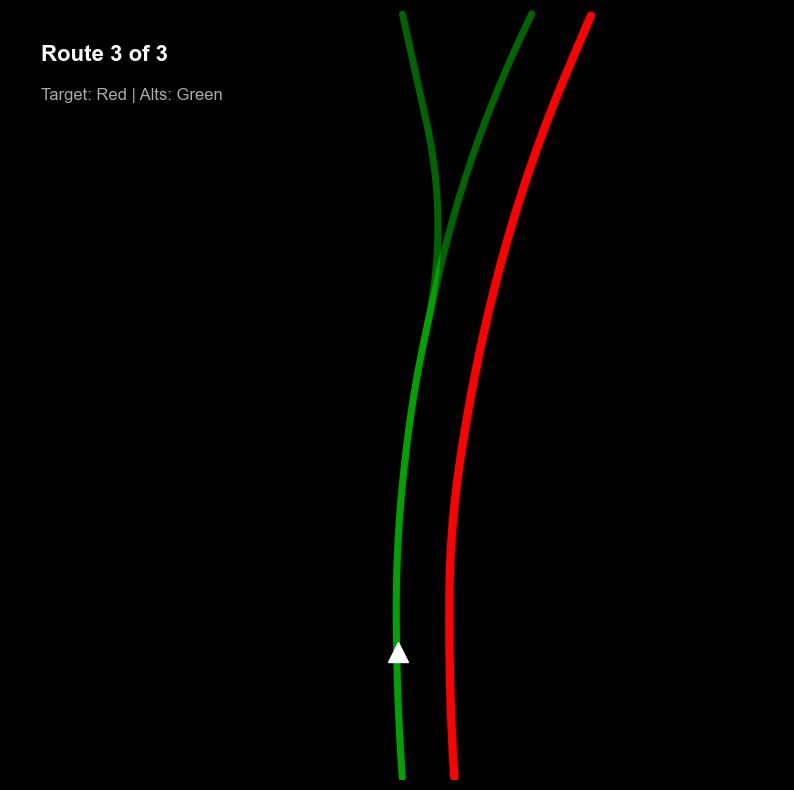

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from nuscenes.nuscenes import NuScenes
from nuscenes.map_expansion.map_api import NuScenesMap

# Make sure inline plotting is enabled for Jupyter
%matplotlib inline 

def test_single_sample_routes_clean(nmap, ego_trans, ego_rot, batches, sample_token):
    """
    Generates N plots for N routes. 
    Map background is removed. Routes only.
    """
    print(f"Found {len(batches)} possible routes for sample: {sample_token}")
    
    for target_idx in range(len(batches)):
        fig, ax = plt.subplots(figsize=(10, 10), facecolor='black')
        ax.set_facecolor('black')
        
        # Set ego-centric boundaries
        ax.set_xlim(-LATERAL_LIMIT, LATERAL_LIMIT)
        ax.set_ylim(-BACKWARD_MAX, FORWARD_MAX)
        ax.axis('off')

        # 1. Plot Alternative Routes (Green, slightly transparent)
        for i, (path_geom, _) in enumerate(batches):
            if i != target_idx:
                ax.plot(path_geom[:, 0], path_geom[:, 1], color='#00FF00', lw=5, alpha=0.4, zorder=5)

        # 2. Plot Target Route (Red, opaque)
        target_geom = batches[target_idx][0]
        ax.plot(target_geom[:, 0], target_geom[:, 1], color='#FF0000', lw=6, zorder=10)
        
        # 3. Plot Ego Vehicle (White triangle)
        ax.plot(0, 0, 'w^', markersize=14, zorder=100) 
        
        # Title/Overlay
        ax.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 4, f"Route {target_idx + 1} of {len(batches)}", color='white', fontsize=16, weight='bold')
        ax.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 7, f"Target: Red | Alts: Green", color='#aaaaaa', fontsize=12)

        plt.show()

import matplotlib.pyplot as plt
import numpy as np
from nuscenes.nuscenes import NuScenes
from nuscenes.map_expansion.map_api import NuScenesMap

# Make sure inline plotting is enabled for Jupyter
%matplotlib inline 

def test_single_sample_routes_clean(nmap, ego_trans, ego_rot, batches, sample_token):
    """
    Generates N plots for N routes. 
    Map background is removed. Routes only.
    """
    print(f"Found {len(batches)} possible routes for sample: {sample_token}")
    
    for target_idx in range(len(batches)):
        fig, ax = plt.subplots(figsize=(10, 10), facecolor='black')
        ax.set_facecolor('black')
        
        # Set ego-centric boundaries
        ax.set_xlim(-LATERAL_LIMIT, LATERAL_LIMIT)
        ax.set_ylim(-BACKWARD_MAX, FORWARD_MAX)
        ax.axis('off')

        # 1. Plot Alternative Routes (Green, slightly transparent)
        for i, (path_geom, _) in enumerate(batches):
            if i != target_idx:
                ax.plot(path_geom[:, 0], path_geom[:, 1], color='#00FF00', lw=5, alpha=0.4, zorder=5)

        # 2. Plot Target Route (Red, opaque)
        target_geom = batches[target_idx][0]
        ax.plot(target_geom[:, 0], target_geom[:, 1], color='#FF0000', lw=6, zorder=10)
        
        # 3. Plot Ego Vehicle (White triangle)
        ax.plot(0, 0, 'w^', markersize=14, zorder=100) 
        
        # Title/Overlay
        ax.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 4, f"Route {target_idx + 1} of {len(batches)}", color='white', fontsize=16, weight='bold')
        ax.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 7, f"Target: Red | Alts: Green", color='#aaaaaa', fontsize=12)

        plt.show()

import random

# --- Find a RANDOM valid sample and test ---
print("Initializing NuScenes...")
# Only run this once in your notebook to save time:
# nusc = NuScenes(version=VERSION, dataroot=DATAROOT, verbose=False)

print("Hunting for a random sample with multiple routes...")

# 1. Get all samples and shuffle them
all_samples = list(nusc.sample)
random.shuffle(all_samples)

map_cache = {}

# 2. Iterate through the randomized list
for sample in all_samples:
    curr_token = sample['token']
    
    # Get location and load map (using cache for speed)
    loc = nusc.get('log', nusc.get('scene', sample['scene_token'])['log_token'])['location']
    if loc not in map_cache:
        map_cache[loc] = NuScenesMap(DATAROOT, loc)
    nmap = map_cache[loc]
    
    ego = nusc.get('ego_pose', nusc.get('sample_data', sample['data']['LIDAR_TOP'])['ego_pose_token'])
    trans, rot = ego['translation'], ego['rotation']
    
    # 3. Process the graph
    node_paths = get_reachable_lanes(nmap, trans, rot)
    if node_paths:
        inf_map = {t: global_to_local(p, trans, rot) for t, p in node_paths.items()}
        batches = get_batches(nmap, inf_map)
        
        # 4. If we find a frame with multiple routes, plot it and stop!
        if len(batches) > 1:
            test_single_sample_routes_clean(nmap, trans, rot, batches, curr_token)
            break

In [75]:
# ================= GEOMETRY HELPERS =================

def get_yaw(q):
    return Quaternion(q).yaw_pitch_roll[0]

def global_to_local(points_global, ego_translation, ego_rotation):
    pts = np.array(points_global)[:, :2] - np.array(ego_translation[:2])
    yaw = get_yaw(ego_rotation)
    c, s = np.cos(-yaw), np.sin(-yaw)
    rot = np.array([[c, -s], [s, c]])
    local = np.dot(pts, rot.T)
    return np.stack([-local[:, 1], local[:, 0]], axis=1)

def crop_forward_sector(local_coords):
    if len(local_coords) == 0: return local_coords
    x, y = local_coords[:, 0], local_coords[:, 1]
    mask = ((y <= FORWARD_MAX) & (y >= -BACKWARD_MAX) & (np.abs(x) <= LATERAL_LIMIT))
    return local_coords[mask]

# ================= FEATURE & VISUAL LOGIC =================

def calculate_feature_matrix_9col(local_points, ids_in_batch, nmap, ego_trans, ego_rot, target_points=50):
    diffs = np.diff(local_points, axis=0)
    dists = np.linalg.norm(diffs, axis=1)
    cum_dist = np.insert(np.cumsum(dists), 0, 0)
    _, idx = np.unique(cum_dist, return_index=True)
    if len(idx) < 3: return None
    
    pts, cum = local_points[idx], cum_dist[idx]
    total_len = cum[-1]
    if total_len < 1.0: return None

    new_dists = np.linspace(0, total_len, target_points)
    interp_pts = interp1d(cum, pts, axis=0)(new_dists)
    
    g = np.gradient(interp_pts, axis=0)
    norm = np.linalg.norm(g, axis=1)[:, np.newaxis]
    norm[norm == 0] = 1.0
    u = g / norm
    g2 = np.gradient(g, axis=0)
    k = (g[:, 0]*g2[:, 1] - g[:, 1]*g2[:, 0]) / (np.power(norm[:, 0], 3) + 1e-6)
    
    yaw = get_yaw(ego_rot)
    c, s = np.cos(yaw), np.sin(yaw)
    rot_inv = np.array([[c, s], [-s, c]])
    remap_pts = np.stack([interp_pts[:, 1], -interp_pts[:, 0]], axis=1)
    pts_global = np.dot(remap_pts, rot_inv) + np.array(ego_trans[:2])
    
    is_int, is_conn = np.zeros(target_points), np.zeros(target_points)
    center = np.mean(pts_global, axis=0)
    radius = (total_len / 2) + 15
    
    try:
        nearby_road = nmap.get_records_in_radius(center[0], center[1], radius, ['road_segment'])['road_segment']
        junction_polys = [nmap.extract_polygon(nmap.get('road_segment', t)['polygon_token']) 
                         for t in nearby_road if nmap.get('road_segment', t).get('is_intersection', False)]
        junction_zone = unary_union(junction_polys) if junction_polys else None
        nearby_conn = set(nmap.get_records_in_radius(center[0], center[1], radius, ['lane_connector'])['lane_connector'])

        for i in range(target_points):
            p_shapely = Point(pts_global[i,0], pts_global[i,1])
            if junction_zone and junction_zone.contains(p_shapely):
                is_int[i] = 1.0
            closest_lane = nmap.get_closest_lane(pts_global[i,0], pts_global[i,1], radius=3.0)
            if closest_lane in nearby_conn:
                is_conn[i] = 1.0
    except: pass

    return np.stack([interp_pts[:, 0], interp_pts[:, 1], u[:, 0], u[:, 1], 
                    np.clip(k, -0.5, 0.5), new_dists/total_len, np.zeros(target_points),
                    is_int, is_conn], axis=1)

def save_batch_visuals_production(nmap, ego_trans, ego_rot, batches, inf_map, sample_token):
    for b_idx, (path_geom, batch_ids) in enumerate(batches):
        num_stages = len(batch_ids) - 1
        for stage in range(1, num_stages + 1):
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), facecolor='black')
            plt.subplots_adjust(wspace=0.02)
            
            for ax in [ax1, ax2]:
                ax.set_facecolor('black')
                ax.set_xlim(-LATERAL_LIMIT, LATERAL_LIMIT)
                ax.set_ylim(-BACKWARD_MAX, FORWARD_MAX)
                ax.axis('off')
                ax.plot(0, 0, 'r^', markersize=14, zorder=100) # Ego position

            active_ids = [batch_ids[stage-1], batch_ids[stage]]
            
            # 1. Background paths
            for t_id, local_pts in inf_map.items():
                if t_id not in active_ids:
                    ax1.plot(local_pts[:, 0], local_pts[:, 1], color='#181818', lw=1.5, zorder=5)

            # 2. Foreground Highlight (High visibility)
            for t_id in active_ids:
                if t_id in inf_map:
                    local_pts = inf_map[t_id]
                    ax1.plot(local_pts[:, 0], local_pts[:, 1], color='#00FF00', lw=10, zorder=50)
                    m = len(local_pts) // 2
                    ax1.text(local_pts[m,0], local_pts[m,1], t_id[:4], color='white', 
                             weight='bold', zorder=60, bbox=dict(facecolor='black', edgecolor='#00FF00', pad=1))

            # 3. Context Map Rendering
            recs = nmap.get_records_in_radius(ego_trans[0], ego_trans[1], 60, ['lane', 'road_segment'])
            for lyr in ['lane', 'road_segment']:
                for t in recs.get(lyr, []):
                    rec = nmap.get(lyr, t)
                    if 'polygon_token' not in rec: continue
                    poly = nmap.extract_polygon(rec['polygon_token'])
                    coords = crop_forward_sector(global_to_local(np.array(poly.exterior.coords)[:,:2], ego_trans, ego_rot))
                    if len(coords) >= 3:
                        ax2.add_patch(MplPolygon(coords, facecolor='#0d0d0d', edgecolor='#1a1a1a', lw=0.5, zorder=1))

            # Overlay Titles
            ax1.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 5, f"BATCH: {b_idx}", color='#00FF00', fontsize=22, weight='bold')
            ax1.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 12, f"STAGE: {stage}", color='#00FF00', fontsize=22, weight='bold')
            ax1.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 19, f"IDs: {active_ids[0][:4]} -> {active_ids[1][:4]}", color='white', fontsize=12)

            plt.savefig(os.path.join(IMAGE_DIR, f"{sample_token}_batch{b_idx}_stage{stage}.png"), facecolor='black', bbox_inches='tight', dpi=100)
            plt.close(fig)

# ================= ENGINES =================

def get_reachable_lanes(nmap, trans, rot):
    ego_lane = nmap.get_closest_lane(trans[0], trans[1], radius=5.0)
    if not ego_lane: return {}
    yaw = get_yaw(rot); ego_fwd = np.array([np.cos(yaw), np.sin(yaw)])
    queue, visited, node_path = deque([ego_lane]), set(), {}
    while queue:
        t = queue.popleft()
        if t in visited: continue
        visited.add(t)
        try:
            pts = nmap.discretize_lanes([t], 0.5)[t]
            node_path[t] = np.array(pts)[:, :2]
            for s in nmap.get_outgoing_lane_ids(t): queue.append(s)
            for adj in [nmap.get('lane', t).get('left_lane_token'), nmap.get('lane', t).get('right_lane_token')]:
                if adj: queue.append(adj)
        except: continue
    return node_path

def get_batches(nmap, inf_map, ego_trans):
    legal = set(inf_map.keys())
    dist_map = {t: np.linalg.norm(inf_map[t][-1] - inf_map[t][0]) for t in legal}
    
    # --- NEW: Identify Ego Lane and Forbidden Predecessors ---
    ego_lane_id = nmap.get_closest_lane(ego_trans[0], ego_trans[1], radius=3.0)
    forbidden_ids = set()
    if ego_lane_id:
        # Get predecessors of the lane the ego is currently on
        try:
            lane_record = nmap.get('lane', ego_lane_id)
        except:
            lane_record = nmap.get('lane_connector', ego_lane_id)
            
        if lane_record and 'predecessor' in lane_record:
            forbidden_ids.update(lane_record['predecessor'])
    # -------------------------------------------------------

    # 1. Directional Root Selection + Predecessor Exclusion
    raw_roots = [t for t in legal if np.min(np.linalg.norm(inf_map[t], axis=1)) <= 5.0]
    
    roots = []
    for r in raw_roots:
        # SKIP if the root is a known predecessor of our current lane
        if r in forbidden_ids:
            continue
            
        pts = inf_map[r]
        # Only keep lanes pointing forward (exit is ahead of entry and ahead of ego)
        if pts[-1, 1] > 0 and pts[-1, 1] > pts[0, 1]:
            roots.append(r)

    roots = sorted(roots, key=lambda t: np.min(np.linalg.norm(inf_map[t], axis=1)))[:5]
    
    # 2. Recursive Path Walking
    def walk(curr, chain, current_dist):
        new_dist = current_dist + dist_map.get(curr, 0)
        if new_dist >= FORWARD_MAX or len(chain) >= 20:
            return [chain]
            
        res = []
        outgoing = nmap.get_outgoing_lane_ids(curr)
        valid_successors = [s for s in outgoing if s in legal and s not in chain]
        
        for s in valid_successors:
            res.extend(walk(s, chain + [s], new_dist))
        
        return res if res else [chain]
    
    all_paths = []
    for r in roots:
        all_paths.extend(walk(r, [r], dist_map.get(r, 0)))
        
    # 3. Aggressive Filtering
    all_paths.sort(key=len, reverse=True)
    unique_paths = []
    seen_sets = [] 
    
    for p in all_paths:
        p_set = set(p)
        is_redundant = False
        for existing_set in seen_sets:
            if p_set.issubset(existing_set):
                is_redundant = True
                break
        if not is_redundant:
            unique_paths.append(p)
            seen_sets.append(p_set)
            
    # 4. Final Stitch
    batches = []
    for p in unique_paths:
        stitched = np.vstack([inf_map[t] for t in p])
        if stitched[-1, 1] > 5.0: 
            batches.append((crop_forward_sector(stitched), p))
        
    return batches

# ================= MAIN PRODUCTION LOOP =================

def main():

    # Collect every available sample token across all scenes
    all_tokens = []
    for scene in nusc.scene:
        curr = scene['first_sample_token']
        while curr:
            all_tokens.append(curr)
            curr = nusc.get('sample', curr)['next']
    
    # Shuffle for true randomization across maps (Boston + Singapore)
    random.seed(42)
    random.shuffle(all_tokens)
    
    map_cache = {}
    count = 0
    pbar = tqdm(total=TARGET_SAMPLE_COUNT, desc="🎲 Processing Randomized Samples")
    
    for token in all_tokens:
        if count >= TARGET_SAMPLE_COUNT: break
        
        sample = nusc.get('sample', token)
        loc = nusc.get('log', nusc.get('scene', sample['scene_token'])['log_token'])['location']
        nmap = map_cache.setdefault(loc, NuScenesMap(DATAROOT, loc))
        
        ego = nusc.get('ego_pose', nusc.get('sample_data', sample['data']['LIDAR_TOP'])['ego_pose_token'])
        trans, rot = ego['translation'], ego['rotation']
        
        node_paths = get_reachable_lanes(nmap, trans, rot)
        if not node_paths: continue
        
        inf_map = {t: global_to_local(p, trans, rot) for t, p in node_paths.items()}
        batches = get_batches(nmap, inf_map)
        
        if batches:
            valid_sample_found = False
            for b_idx, (path, ids) in enumerate(batches):
                matrix = calculate_feature_matrix_9col(path, ids, nmap, trans, rot)
                if matrix is not None:
                    torch.save(torch.from_numpy(matrix).float(), os.path.join(PT_DIR, f"{token}_batch{b_idx}.pt"))
                    valid_sample_found = True
            
            if valid_sample_found:
                # Save the images with Batch/Stage titles and 10px green highlighting
                save_batch_visuals_production(nmap, trans, rot, batches, inf_map, token)
                count += 1
                pbar.update(1)
            
            if count % 10 == 0: gc.collect() # Regular memory clearing

Initializing NuScenes...
Hunting for a random sample with multiple routes...

[VISUALIZER] Plotting 3 routes for sample: 14d67f4f3de84202adb683652a1093e7
  Route 1 (2 nodes): 5796c3 -> 37eb45
  Route 2 (2 nodes): f6fb03 -> 706849
  Route 3 (1 nodes): f28914


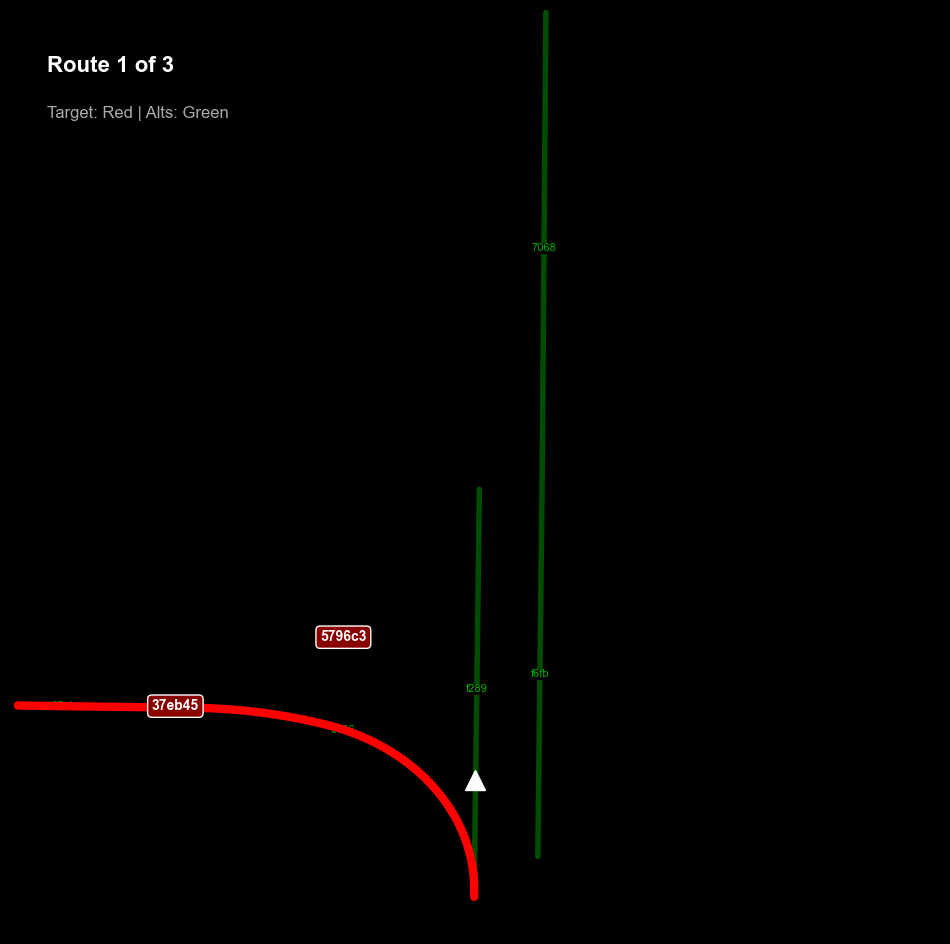

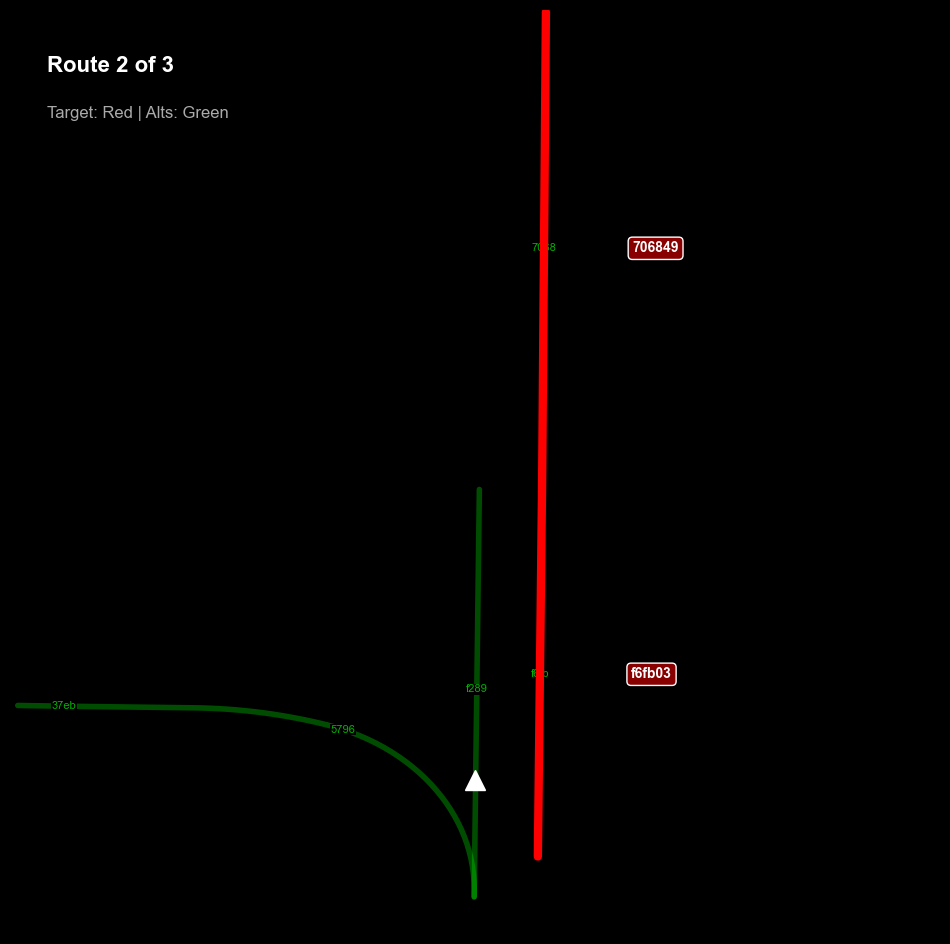

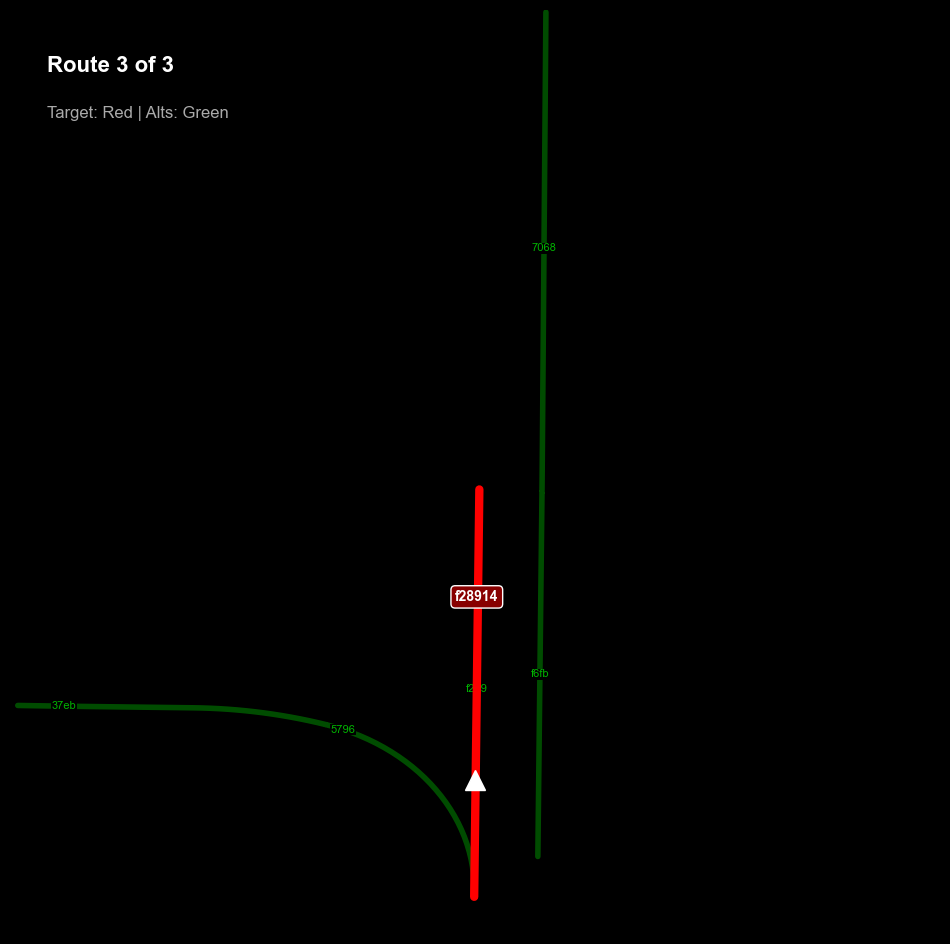

In [98]:
import matplotlib.pyplot as plt
import numpy as np
from nuscenes.nuscenes import NuScenes
from nuscenes.map_expansion.map_api import NuScenesMap

# Make sure inline plotting is enabled for Jupyter
%matplotlib inline 

def test_single_sample_routes_clean(nmap, ego_trans, ego_rot, batches, inf_map, sample_token):
    print(f"\n[VISUALIZER] Plotting {len(batches)} routes for sample: {sample_token}")
    
    for i, (_, ids) in enumerate(batches):
        short_ids = [t[:6] for t in ids] 
        print(f"  Route {i + 1} ({len(ids)} nodes): {' -> '.join(short_ids)}")
    
    for target_idx in range(len(batches)):
        fig, ax = plt.subplots(figsize=(12, 12), facecolor='black')
        ax.set_facecolor('black')
        
        ax.set_xlim(-LATERAL_LIMIT, LATERAL_LIMIT)
        ax.set_ylim(-BACKWARD_MAX, FORWARD_MAX)
        ax.axis('off')

        # --- Anti-Collision Logic ---
        placed_text_positions = []

        def get_valid_text_pos(base_x, base_y, threshold=4.0):
            x, y = base_x, base_y
            offset_step = 2.0
            angle = 0
            # Keep spiraling outward if the spot is taken
            while any(np.hypot(x - px, y - py) < threshold for px, py in placed_text_positions) and angle < 1080:
                x = base_x + np.cos(np.radians(angle)) * offset_step
                y = base_y + np.sin(np.radians(angle)) * offset_step
                angle += 45
                if angle % 360 == 0:
                    offset_step += 2.0 # Expand spiral radius
            return x, y
        # ----------------------------

        # 1. Plot Alternative Routes & Labels
        for i, (path_geom, ids) in enumerate(batches):
            if i != target_idx:
                ax.plot(path_geom[:, 0], path_geom[:, 1], color='#00FF00', lw=4, alpha=0.3, zorder=5)
                
                # Inside the labeling loop in test_single_sample_routes_clean:
            for t in ids:
                pts = inf_map[t]
                # Check if the START of this lane is within bounds
                if pts[0, 1] <= FORWARD_MAX and pts[0, 1] >= -BACKWARD_MAX:
                    # ... proceed with labeling ...
                    # Only label if the lane is actually visible within our bounding box
                    mask = (pts[:, 1] <= FORWARD_MAX) & (pts[:, 1] >= -BACKWARD_MAX) & (np.abs(pts[:, 0]) <= LATERAL_LIMIT)
                    valid_pts = pts[mask]
                    if len(valid_pts) > 0:
                        mid = valid_pts[len(valid_pts) // 2]
                        tx, ty = get_valid_text_pos(mid[0], mid[1], threshold=3.5)
                        placed_text_positions.append((tx, ty))
                        ax.text(tx, ty, t[:4], color='#00FF00', fontsize=8, alpha=0.7,
                                ha='center', va='center', zorder=6,
                                bbox=dict(facecolor='black', edgecolor='none', pad=0.5))

        # 2. Plot Target Route & Bold Labels
        target_geom, target_ids = batches[target_idx]
        ax.plot(target_geom[:, 0], target_geom[:, 1], color='#FF0000', lw=6, zorder=10)
        
        for t in target_ids:
            pts = inf_map[t]
            mask = (pts[:, 1] <= FORWARD_MAX) & (pts[:, 1] >= -BACKWARD_MAX) & (np.abs(pts[:, 0]) <= LATERAL_LIMIT)
            valid_pts = pts[mask]
            if len(valid_pts) > 0:
                mid = valid_pts[len(valid_pts) // 2]
                tx, ty = get_valid_text_pos(mid[0], mid[1], threshold=5.0)
                placed_text_positions.append((tx, ty))
                # Target text gets a nice red badge so it pops
                ax.text(tx, ty, t[:6], color='white', fontsize=10, weight='bold',
                        ha='center', va='center', zorder=15,
                        bbox=dict(facecolor='#880000', edgecolor='white', boxstyle='round,pad=0.3'))
        
        ax.plot(0, 0, 'w^', markersize=14, zorder=100) 
        
        ax.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 4, f"Route {target_idx + 1} of {len(batches)}", color='white', fontsize=16, weight='bold')
        ax.text(-LATERAL_LIMIT + 2, FORWARD_MAX - 7, f"Target: Red | Alts: Green", color='#aaaaaa', fontsize=12)

        plt.show()

import random

# --- Find a RANDOM valid sample and test ---
print("Initializing NuScenes...")
# Only run this once in your notebook to save time:
# nusc = NuScenes(version=VERSION, dataroot=DATAROOT, verbose=False)

print("Hunting for a random sample with multiple routes...")

# 1. Get all samples and shuffle them
all_samples = list(nusc.sample)
random.shuffle(all_samples)

map_cache = {}

# 2. Iterate through the randomized list
for sample in all_samples:
    curr_token = sample['token']
    
    # Get location and load map (using cache for speed)
    loc = nusc.get('log', nusc.get('scene', sample['scene_token'])['log_token'])['location']
    if loc not in map_cache:
        map_cache[loc] = NuScenesMap(DATAROOT, loc)
    nmap = map_cache[loc]
    
    ego = nusc.get('ego_pose', nusc.get('sample_data', sample['data']['LIDAR_TOP'])['ego_pose_token'])
    trans, rot = ego['translation'], ego['rotation']
    
    # 3. Process the graph
    node_paths = get_reachable_lanes(nmap, trans, rot)
    if node_paths:
        inf_map = {t: global_to_local(p, trans, rot) for t, p in node_paths.items()}
        batches = get_batches(nmap, inf_map, trans)
        
        # 4. If we find a frame with multiple routes, plot it and stop!
        if len(batches) > 1:
            test_single_sample_routes_clean(nmap, trans, rot, batches, inf_map, curr_token)
            break

In [ ]:
import os
import torch
import numpy as np
import matplotlib
matplotlib.use('Agg') 
import matplotlib.pyplot as plt
from tqdm import tqdm
from pyquaternion import Quaternion
from collections import deque
from scipy.interpolate import interp1d
import gc
import random

from nuscenes.nuscenes import NuScenes
from nuscenes.map_expansion.map_api import NuScenesMap

# ================= CONFIGURATION =================
DATAROOT = "/mount/arbeitsdaten/analysis/rasoulta/nuscenes/nuscenes_meta/"
VERSION = "v1.0-trainval"

IMAGE_DIR = "/mount/studenten/projects/rasoulta/dataset/caption-visuals"
PT_DIR = "/mount/studenten/projects/rasoulta/dataset/train_processed_labeled"

TARGET_SAMPLE_COUNT = 5000  # High limit, safety break will handle the 1000 png cap
MAX_PNG_COUNT = 1000
FORWARD_MAX, BACKWARD_MAX, LATERAL_LIMIT = 50.0, 10.0, 25.0

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(PT_DIR, exist_ok=True)

# ================= GEOMETRY HELPERS =================

def get_yaw(q):
    return Quaternion(q).yaw_pitch_roll[0]

def global_to_local(points_global, ego_translation, ego_rotation):
    pts = np.array(points_global)[:, :2] - np.array(ego_translation[:2])
    yaw = get_yaw(ego_rotation)
    c, s = np.cos(-yaw), np.sin(-yaw)
    rot = np.array([[c, -s], [s, c]])
    local = np.dot(pts, rot.T)
    # x is lateral, y is forward
    return np.stack([-local[:, 1], local[:, 0]], axis=1)

def crop_forward_sector(local_coords):
    if len(local_coords) == 0: return local_coords
    x, y = local_coords[:, 0], local_coords[:, 1]
    mask = ((y <= FORWARD_MAX) & (y >= -BACKWARD_MAX) & (np.abs(x) <= LATERAL_LIMIT))
    return local_coords[mask]

# ================= ROUTING ENGINE =================

def get_batches(nmap, inf_map, ego_trans):
    legal = set(inf_map.keys())
    dist_map = {t: np.linalg.norm(inf_map[t][-1] - inf_map[t][0]) for t in legal}
    
    # Identify current lane and forbidden predecessors
    ego_lane_id = nmap.get_closest_lane(ego_trans[0], ego_trans[1], radius=3.0)
    forbidden_ids = set()
    if ego_lane_id:
        try:
            rec = nmap.get('lane', ego_lane_id)
        except:
            rec = nmap.get('lane_connector', ego_lane_id)
        if rec and 'predecessor' in rec:
            forbidden_ids.update(rec['predecessor'])

    # Root selection: proximity + forward-facing + not a predecessor
    raw_roots = [t for t in legal if np.min(np.linalg.norm(inf_map[t], axis=1)) <= 5.0]
    roots = []
    for r in raw_roots:
        if r in forbidden_ids: continue
        pts = inf_map[r]
        if pts[-1, 1] > 0 and pts[-1, 1] > pts[0, 1]:
            roots.append(r)
    roots = sorted(roots, key=lambda t: np.min(np.linalg.norm(inf_map[t], axis=1)))[:5]
    
    def walk(curr, chain, current_dist):
        new_dist = current_dist + dist_map.get(curr, 0)
        if new_dist >= FORWARD_MAX or len(chain) >= 15: 
            return [chain]
        res = []
        outgoing = [s for s in nmap.get_outgoing_lane_ids(curr) if s in legal and s not in chain]
        for s in outgoing:
            res.extend(walk(s, chain + [s], new_dist))
        return res if res else [chain]
    
    all_paths = []
    for r in roots:
        all_paths.extend(walk(r, [r], dist_map.get(r, 0)))
        
    all_paths.sort(key=len, reverse=True)
    unique_paths, seen_sets = [], []
    for p in all_paths:
        p_set = set(p)
        if not any(p_set.issubset(s) for s in seen_sets):
            unique_paths.append(p)
            seen_sets.append(p_set)
            
    batches = []
    for p in unique_paths:
        stitched = np.vstack([inf_map[t] for t in p])
        cropped = crop_forward_sector(stitched)
        if len(cropped) > 2 and cropped[-1, 1] > 5.0:
            batches.append((cropped, p))
    return batches

# ================= VISUALS & ENCODING =================

def save_production_visuals(batches, sample_token):
    for target_idx, (target_geom, _) in enumerate(batches):
        fig, ax = plt.subplots(figsize=(10, 10), facecolor='black')
        ax.set_facecolor('black')
        ax.set_xlim(-LATERAL_LIMIT, LATERAL_LIMIT)
        ax.set_ylim(-BACKWARD_MAX, FORWARD_MAX)
        ax.axis('off')

        # 1. Alts (Green)
        for i, (path_geom, _) in enumerate(batches):
            if i != target_idx:
                ax.plot(path_geom[:, 0], path_geom[:, 1], color='#00FF00', lw=4, alpha=0.25, zorder=5)

        # 2. Target (Red)
        ax.plot(target_geom[:, 0], target_geom[:, 1], color='#FF0000', lw=6, zorder=10)
        ax.plot(0, 0, 'w^', markersize=12, zorder=100) 
        
        plt.savefig(os.path.join(IMAGE_DIR, f"{sample_token}_r{target_idx}.png"), facecolor='black', bbox_inches='tight', dpi=100)
        plt.close(fig)

def calculate_feature_matrix(local_points, target_points=50):
    diffs = np.diff(local_points, axis=0)
    dists = np.linalg.norm(diffs, axis=1)
    cum_dist = np.insert(np.cumsum(dists), 0, 0)
    _, idx = np.unique(cum_dist, return_index=True)
    if len(idx) < 3: return None
    pts, cum = local_points[idx], cum_dist[idx]
    if cum[-1] < 1.0: return None

    new_dists = np.linspace(0, cum[-1], target_points)
    interp_pts = interp1d(cum, pts, axis=0)(new_dists)
    g = np.gradient(interp_pts, axis=0)
    u = g / (np.linalg.norm(g, axis=1)[:, np.newaxis] + 1e-6)
    
    # 9-col matrix [x, y, ux, uy, kappa, s, zero, zero, zero]
    # (Simplified placeholders for intersection/connector to keep logic focused)
    matrix = np.zeros((target_points, 9))
    matrix[:, :2] = interp_pts
    matrix[:, 2:4] = u
    matrix[:, 5] = new_dists / cum[-1]
    return matrix

# ================= MAIN LOOP =================

def main():
    nusc = NuScenes(version=VERSION, dataroot=DATAROOT, verbose=False)
    all_tokens = [s['token'] for s in nusc.sample]
    random.shuffle(all_tokens)
    
    map_cache = {}
    processed_count = 0
    pbar = tqdm(total=TARGET_SAMPLE_COUNT, desc="🚀 Processing")
    
    for token in all_tokens:
        # SAFETY CHECK: Stop if we hit 1000 PNGs
        if processed_count % 100 == 0:
            current_pngs = len([f for f in os.listdir(IMAGE_DIR) if f.endswith('.png')])
            if current_pngs >= MAX_PNG_COUNT:
                print(f"\n[STOP] Reached {current_pngs} PNGs. Terminating.")
                break

        sample = nusc.get('sample', token)
        loc = nusc.get('log', nusc.get('scene', sample['scene_token'])['log_token'])['location']
        if loc not in map_cache: map_cache[loc] = NuScenesMap(DATAROOT, loc)
        nmap = map_cache[loc]
        
        ego = nusc.get('ego_pose', nusc.get('sample_data', sample['data']['LIDAR_TOP'])['ego_pose_token'])
        trans, rot = ego['translation'], ego['rotation']
        
        # Build local reachability map
        ego_lane = nmap.get_closest_lane(trans[0], trans[1], radius=5.0)
        if not ego_lane: continue
        
        queue, visited, node_paths = deque([ego_lane]), set(), {}
        while queue:
            t = queue.popleft()
            if t in visited: continue
            visited.add(t)
            try:
                pts = nmap.discretize_lanes([t], 0.5)[t]
                node_paths[t] = np.array(pts)[:, :2]
                for s in nmap.get_outgoing_lane_ids(t): queue.append(s)
            except: continue

        inf_map = {t: global_to_local(p, trans, rot) for t, p in node_paths.items()}
        batches = get_batches(nmap, inf_map, trans)
        
        if batches:
            success = False
            for b_idx, (path, _) in enumerate(batches):
                matrix = calculate_feature_matrix(path)
                if matrix is not None:
                    torch.save(torch.from_numpy(matrix).float(), os.path.join(PT_DIR, f"{token}_r{b_idx}.pt"))
                    success = True
            
            if success:
                save_production_visuals(batches, token)
                processed_count += 1
                pbar.update(1)
            
        if processed_count % 20 == 0: gc.collect()

if __name__ == "__main__":
    main()